In [1]:
"""
SMART ENERGY SYSTEM - DATA PREPROCESSING (REAL DATASET)
Author:
Roshan
Vatsal
Zeel
"""

# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SMART ENERGY SYSTEM - DATA PREPROCESSING")
print("="*80)

SMART ENERGY SYSTEM - DATA PREPROCESSING


In [2]:
# ===============================
# STEP 1: LOAD DATASET (UPLOAD IN COLAB FIRST)
# ===============================

from google.colab import files
uploaded = files.upload()   # Upload your CSV here

df = pd.read_csv(list(uploaded.keys())[0])

print("\n✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape}")

Saving final_smart_energy_dataset.csv to final_smart_energy_dataset.csv

✅ Dataset Loaded Successfully!
Shape: (20000, 22)


In [3]:
# ===============================
# STEP 2: DATA OVERVIEW
# ===============================

print("\n📊 Dataset Info:")
print(df.info())

print("\n📈 Statistical Summary:")
print(df.describe())

print("\n🔍 Missing Values:")
print(df.isnull().sum())


📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 20000 non-null  object 
 1   home_id                   20000 non-null  object 
 2   energy_consumption_kWh    20000 non-null  float64
 3   power_consumption_W       19999 non-null  float64
 4   voltage                   20000 non-null  int64  
 5   current                   20000 non-null  float64
 6   temperature_setting_C     20000 non-null  int64  
 7   occupancy_status          19999 non-null  object 
 8   appliance                 19997 non-null  object 
 9   usage_duration_minutes    20000 non-null  int64  
 10  device_status             20000 non-null  object 
 11  room_location             19999 non-null  object 
 12  season                    20000 non-null  object 
 13  day_of_week               20000 non-null  ob

In [4]:
# ===============================
# STEP 3: HANDLE MISSING VALUES
# ===============================

# Numerical
df["power_consumption_W"].fillna(df["power_consumption_W"].mean(), inplace=True)

# Categorical
df["occupancy_status"].fillna(df["occupancy_status"].mode()[0], inplace=True)
df["appliance"].fillna(df["appliance"].mode()[0], inplace=True)
df["room_location"].fillna(df["room_location"].mode()[0], inplace=True)

print("\n✅ Missing values handled")


✅ Missing values handled


In [5]:
# ===============================
# STEP 4: FEATURE ENGINEERING
# ===============================

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month

print("\n✅ Feature engineering done")


✅ Feature engineering done


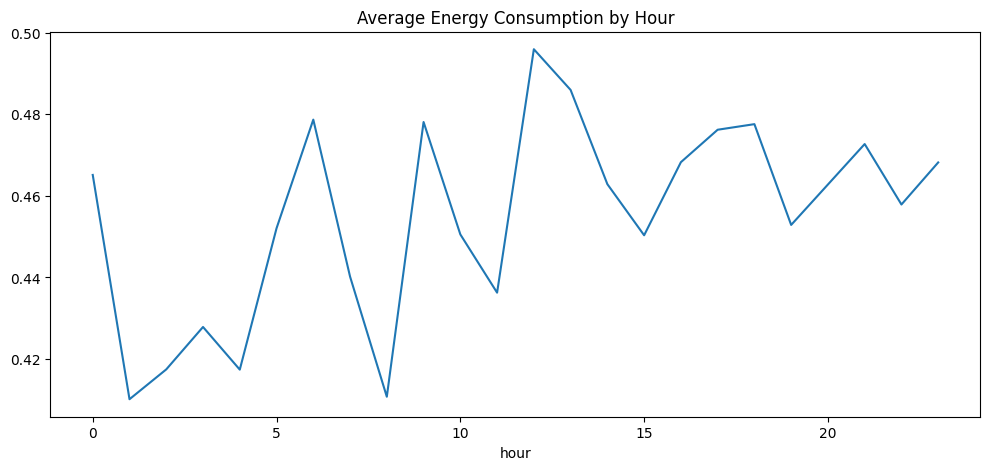

In [7]:
# ===============================
# STEP 5: VISUALIZATION
# ===============================

plt.figure(figsize=(12,5))
df.groupby("hour")["energy_consumption_kWh"].mean().plot()
plt.title("Average Energy Consumption by Hour")
plt.show()


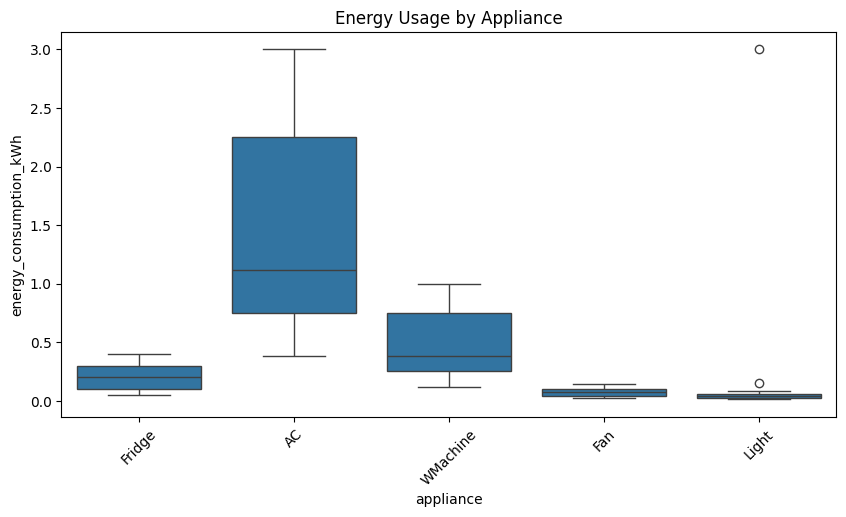

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(x="appliance", y="energy_consumption_kWh", data=df)
plt.xticks(rotation=45)
plt.title("Energy Usage by Appliance")
plt.show()

In [9]:
# ===============================
# STEP 7: NORMALIZATION
# ===============================

from sklearn.preprocessing import MinMaxScaler

features = [
    "energy_consumption_kWh",
    "power_consumption_W",
    "temperature_setting_C",
    "current",
    "hour_of_day",
    "usage_duration_minutes",
    "peak_hour_flag"
]

scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

print("\n✅ Data normalized")


✅ Data normalized


In [10]:
# ===============================
# STEP 8: CREATE LSTM SEQUENCES
# ===============================

def create_sequences(data, seq_length=24):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[features].iloc[i:i+seq_length].values)
        y.append(data["energy_consumption_kWh"].iloc[i+seq_length])

    return np.array(X), np.array(y)

X, y = create_sequences(df)

print("\n📊 LSTM Data Shape:")
print("X:", X.shape)
print("y:", y.shape)


📊 LSTM Data Shape:
X: (19976, 24, 7)
y: (19976,)


In [11]:
# ===============================
# STEP 9: SAVE FILES (COLAB SAFE)
# ===============================

os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

import joblib

joblib.dump(scaler, "models/scaler.pkl")
np.save("data/processed/X.npy", X)
np.save("data/processed/y.npy", y)

print("\n✅ Files saved locally")



✅ Files saved locally


In [12]:
# ===============================
# STEP 10: DOWNLOAD FILES
# ===============================

from google.colab import files

files.download("models/scaler.pkl")
files.download("data/processed/X.npy")
files.download("data/processed/y.npy")

print("\n🎉 DATA PREPROCESSING COMPLETE!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 DATA PREPROCESSING COMPLETE!
